In [ ]:
import marimo as mo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import r2_score, mean_squared_error

# set consistent style for plots
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

# 🧪 LAB: Partial Least Squares Regression

In this lab, you will explore **Partial Least Squares (PLS) Regression**, a powerful technique for modeling relationships between high-dimensional, collinear predictors and a continuous outcome. You will begin with a **group discussion** after reading about the method. Next, you will become familiar with its implementation in `scikit-learn` by **recreating and reflecting on one of their tutorials**. Finally, you will apply PLS to a **real-world chemoinformatics dataset** that includes binary molecular fingerprints as predictors and a continuous permeability outcome for a set of chemical compounds.

PLS is particularly useful when the number of predictors is large and highly correlated, making traditional regression methods unstable or ineffective. You will also compare PLS with an alternative predictive model that also involves a dimensionality-reduction approach: **Penalized Principal Component Regression (PCR)**.

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

## 1. Reading & Group Discussion (10 Points)

Carefully read **Sections 6.2 and 6.3** of the *An Introduction to Statistical Learning* book (Reference B). The first section introduces Principal Component Regression (PCR), which we already covered in a previous class. The second section, instead, introduces Partial Least Squares (PLS).

After reviewing the content, discuss with your group and then answer the following questions:

a. What is the key difference between Principal Component Regression (PCR) and Partial Least Squares (PLS)

b. Why might PCR fail to find directions that are useful for predicting the response `Y`?

c. In PLS, how is the first direction `Z₁` computed?

d. What are some similarities and differences between PLS and penalized regression?

### Group Discussion Answers

#### a. Key Difference Between PCR and PLS
The key distinction is that PCR is an unsupervised dimension reduction method, while PLS is a supervised one. PCR computes its directions $Z_1, \dots, Z_M$ from the predictor matrix $\mathbf{X}$ alone, selecting linear combinations that maximize variance among the features; the response $Y$ plays no role in choosing them. PLS uses $Y$ as well: each component is constructed to explain predictor variance while also maximizing covariance with the response.

#### b. Why PCR Might Fail to Find Directions Useful for Predicting $Y$
PCR operates on the assumption that the directions along which $\mathbf{X}$ varies most are also the ones useful for predicting $Y$, and the method provides no guarantee of this. If the true relationship with $Y$ runs along a direction of low variance in $\mathbf{X}$ (or the dominant high-variance components mostly reflect noise), PCR discards that direction when it retains only the first few components. A low-dimensional PCR model can then explain most of the variance in $\mathbf{X}$ while having almost no predictive power for $Y$.

#### c. How the First Direction $Z_1$ is Computed in PLS
The predictors and the response are standardized first (mean 0, unit variance), as the reading recommends before fitting PLS. Each loading $\phi_{j1}$ is then set equal to the coefficient from the simple linear regression of $Y$ onto $X_j$, which one can show is proportional to the correlation between $Y$ and $X_j$ (equivalently the covariance, once both are standardized):
   $$\phi_{j1} \propto \text{Cov}(X_j, Y)$$
The first component is the normalized linear combination
   $$Z_1 = \sum_{j=1}^p \phi_{j1} X_j \quad \text{subject to} \quad \sum_{j=1}^p \phi_{j1}^2 = 1$$
Because each weight reflects the corresponding feature's relationship with the response, the predictors most strongly correlated with $Y$ individually receive the largest loadings.

#### d. Similarities and Differences Between PLS and Penalized Regression
The two methods address the same problem: ordinary least squares is unstable when $p$ is large and the predictors are collinear. Both accept some bias in exchange for a substantial reduction in variance, and both rely on cross-validation to select their tuning parameter (the number of components $M$ in PLS, the penalty strength $\lambda$/$\alpha$ in Ridge/Lasso/ElasticNet). The final model is linear in either case, $\hat{Y} = \beta_0 + \sum_{j=1}^p \beta_j X_j$.

They differ in mechanism. PLS projects $\mathbf{X}$ onto an $M$-dimensional subspace and fits OLS on the latent scores, while penalized regression keeps all $p$ original predictors and adds a penalty term ($L_2$ for Ridge, $L_1$ for Lasso) to the loss. This choice determines sparsity: standard PLS is dense like Ridge, whereas the $L_1$ methods (Lasso, ElasticNet) can shrink coefficients exactly to zero and therefore perform feature selection. Computationally, penalized regression optimizes a single convex objective over the original predictors, while PLS constructs its components sequentially, deflating $\mathbf{X}$ and $Y$ after each one.

## 2. Recreate, Explain, Experiment & Reflect (35 points)

Follow this tutorial on Partial Least Squares (PLS) from the official scikit-learn documentation:

🔗 [scikit-learn: PLS regression example](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Your goal is to **recreate the PLS portion of the tutorial in this notebook**, and make sure you understand what each part of the code is doing. This will give you the opportunity to build intuition for how PLS works. Be thorough in your answers and interpretations — this will help you when working with real data later in this lab assignment.

### a. Recreate
- Load the dataset used in the tutorial. Make sure to create a training/reporting partition.
- Fit a `PLSRegression` model with 1 component.

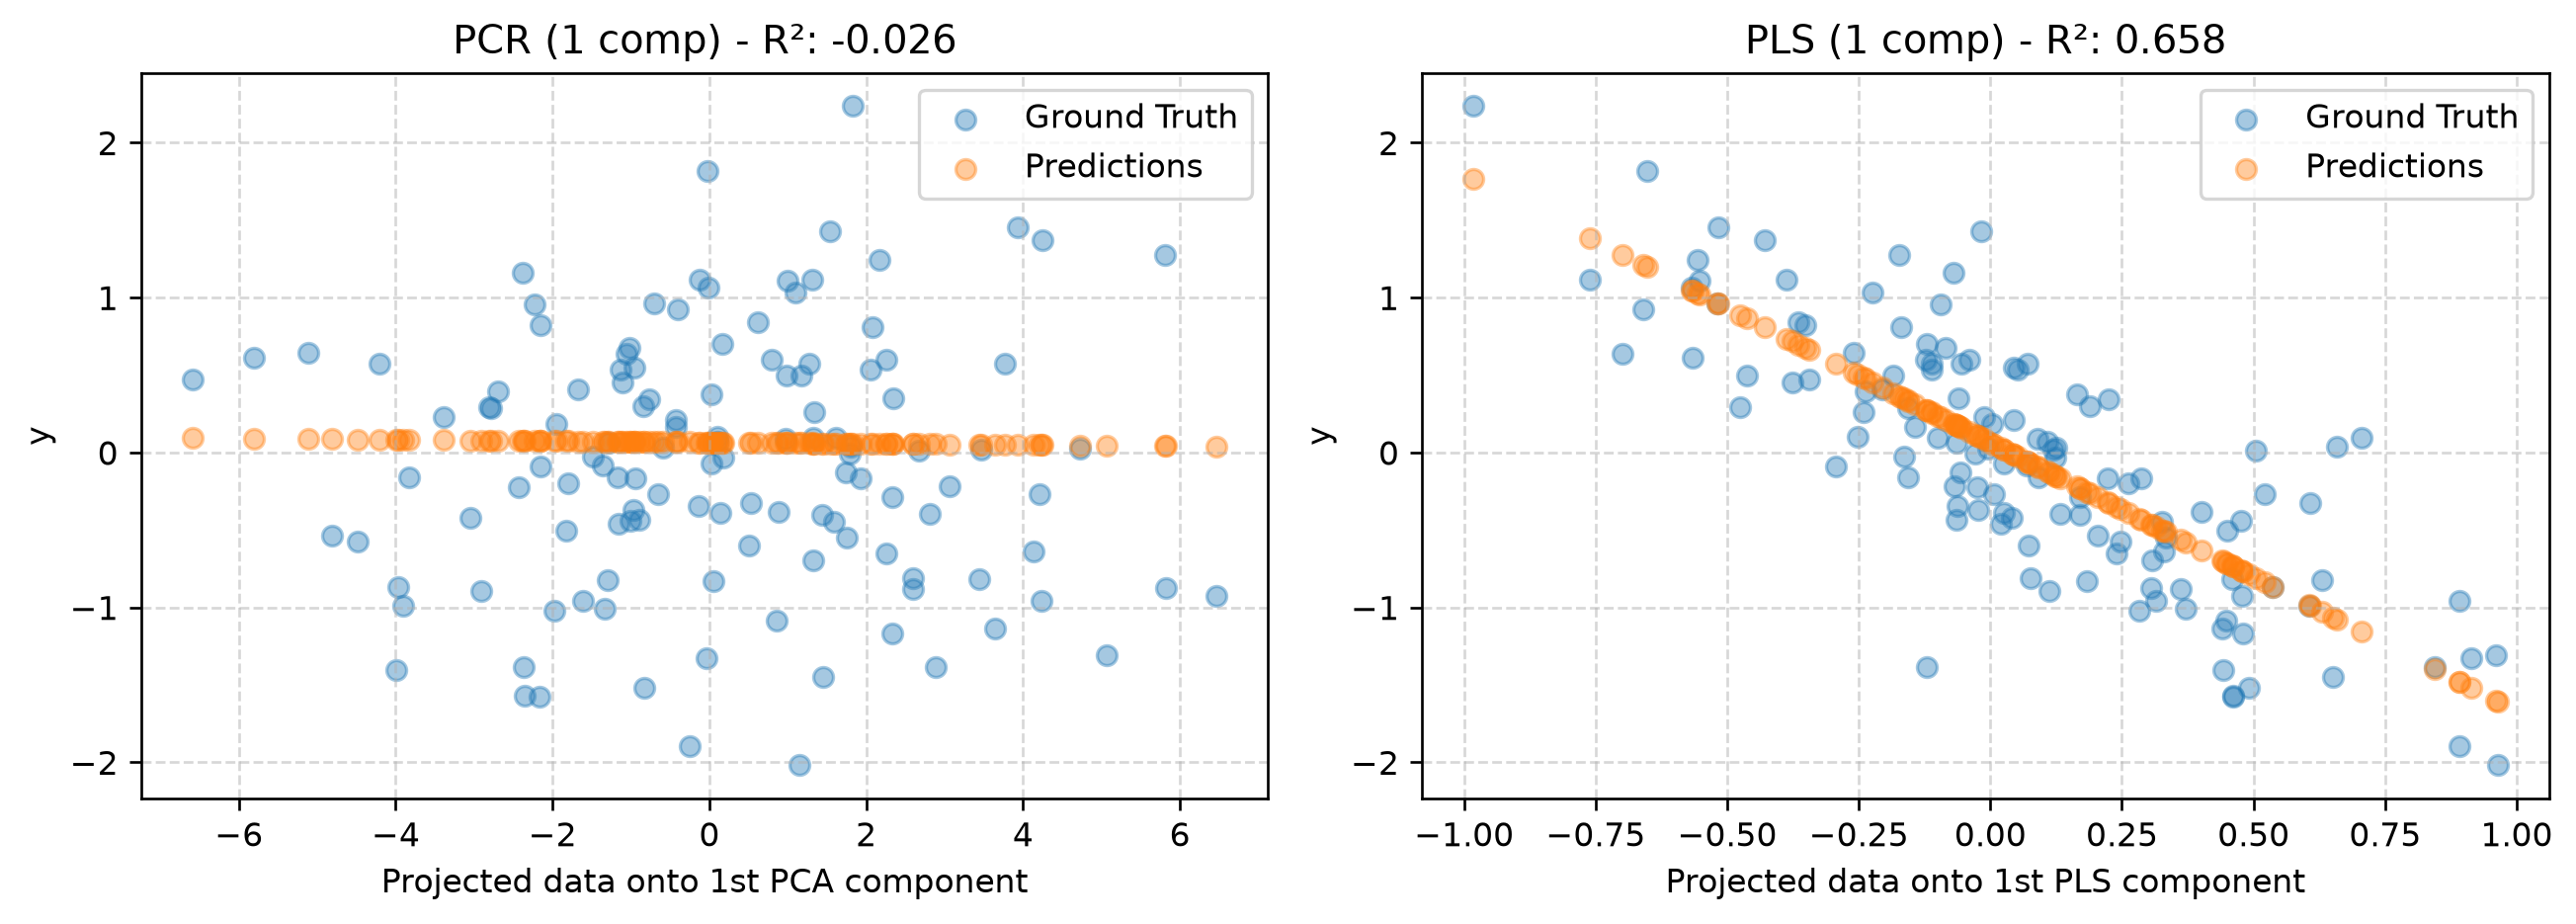

PCR (1 component) Test R²: -0.0263
PLS (1 component) Test R²: 0.6583


In [ ]:
# step 1: generate synthetic 2d dataset where the target y aligns with the low-variance direction
rng_toy = np.random.RandomState(0)
n_samples_toy = 500
cov_toy = [[3, 3], [3, 4]]
X_toy = rng_toy.multivariate_normal(mean=[0, 0], cov=cov_toy, size=n_samples_toy)

# fit pca on x to find principal directions
pca_raw = PCA(n_components=2).fit(X_toy)

# construct target y strongly correlated with the 2nd principal component (the low-variance direction)
y_toy = X_toy.dot(pca_raw.components_[1]) + rng_toy.normal(size=n_samples_toy) / 2.0

# step 2: split into training (75%) and reporting (25%) partitions
X_train_toy, X_test_toy, y_train_toy, y_test_toy = train_test_split(
    X_toy, y_toy, test_size=0.25, random_state=rng_toy
)

# step 3: fit pcr (pca with 1 component + linear regression) and pls (1 component)
pcr_1comp = make_pipeline(StandardScaler(), PCA(n_components=1), LinearRegression())
pcr_1comp.fit(X_train_toy, y_train_toy)
pca_step = pcr_1comp.named_steps["pca"]

pls_1comp = PLSRegression(n_components=1)
pls_1comp.fit(X_train_toy, y_train_toy)

# step 4: visualize projected data and compare model performance on reporting set
fig_toy, axes_toy = plt.subplots(1, 2, figsize=(11, 4))

# pcr plot
axes_toy[0].scatter(pca_step.transform(X_test_toy), y_test_toy, alpha=0.4, label="Ground Truth", color="tab:blue")
axes_toy[0].scatter(
    pca_step.transform(X_test_toy), pcr_1comp.predict(X_test_toy), alpha=0.4, label="Predictions", color="tab:orange"
)
axes_toy[0].set_xlabel("Projected data onto 1st PCA component")
axes_toy[0].set_ylabel("y")
axes_toy[0].set_title(f"PCR (1 comp) - R²: {pcr_1comp.score(X_test_toy, y_test_toy):.3f}")
axes_toy[0].legend()
axes_toy[0].grid(True, linestyle="--", alpha=0.5)

# pls plot
axes_toy[1].scatter(pls_1comp.transform(X_test_toy), y_test_toy, alpha=0.4, label="Ground Truth", color="tab:blue")
axes_toy[1].scatter(
    pls_1comp.transform(X_test_toy), pls_1comp.predict(X_test_toy), alpha=0.4, label="Predictions", color="tab:orange"
)
axes_toy[1].set_xlabel("Projected data onto 1st PLS component")
axes_toy[1].set_ylabel("y")
axes_toy[1].set_title(f"PLS (1 comp) - R²: {pls_1comp.score(X_test_toy, y_test_toy):.3f}")
axes_toy[1].legend()
axes_toy[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"PCR (1 component) Test R²: {pcr_1comp.score(X_test_toy, y_test_toy):.4f}")
print(f"PLS (1 component) Test R²: {pls_1comp.score(X_test_toy, y_test_toy):.4f}")

### b. Explain
For **every block of code**, add a markdown cell that explains:

- What is the goal of this step?
- Why is this important in a PLS regression pipeline?
- What does the output mean or tell us?

### Step-by-Step Code Explanation

#### Block 1, synthetic data generation
The goal of this step is to construct a dataset in which the predictive signal lies in the direction PCA would rank last. We sample 500 points from a 2D Gaussian with covariance `[[3, 3], [3, 4]]`, so the two features are strongly correlated and PC1 captures most of the variance, and then define the response as `y = X @ pca.components_[1] + noise/2`, aligning it with the second principal component. The direction of least variance in `X` is therefore the one that actually predicts `y`, which is precisely the setting in which unsupervised dimension reduction fails.

#### Block 2, training and reporting partition
`train_test_split` sets aside 25% of the samples so that every reported score is computed on data the models were not fit to. Without this partition the reported metrics would describe fit on the training observations, which would hide overfitting.

#### Block 3, fitting the two 1-component models
Both models are restricted to a single direction, and this constraint is what distinguishes them. PCR (PCA followed by OLS) retains the direction of maximum variance in $\mathbf{X}$ and therefore misses the predictive signal entirely; its reporting $R^2$ is negative ($\approx -0.03$, no better than predicting the mean). PLS consults $y$ when constructing its component, so it recovers the predictive direction and reaches $R^2 \approx 0.658$ on the same held-out data.

### c. Experiment
Make the following changes:
- Change the number of components to **2 components** and fit again the model.
- Plot the **predicted vs. actual** response values on the reporting set.
- Report **R²** and **Mean Squared Error (MSE)** for your model
- On the reporting set, create scatter plots showing each component on X against y. (Hint: Use the `transform` method applied to X to get each component). In the title, show the correlation coefficient between both variables. Your first component should correlate more (in magnitude) with the outcome.

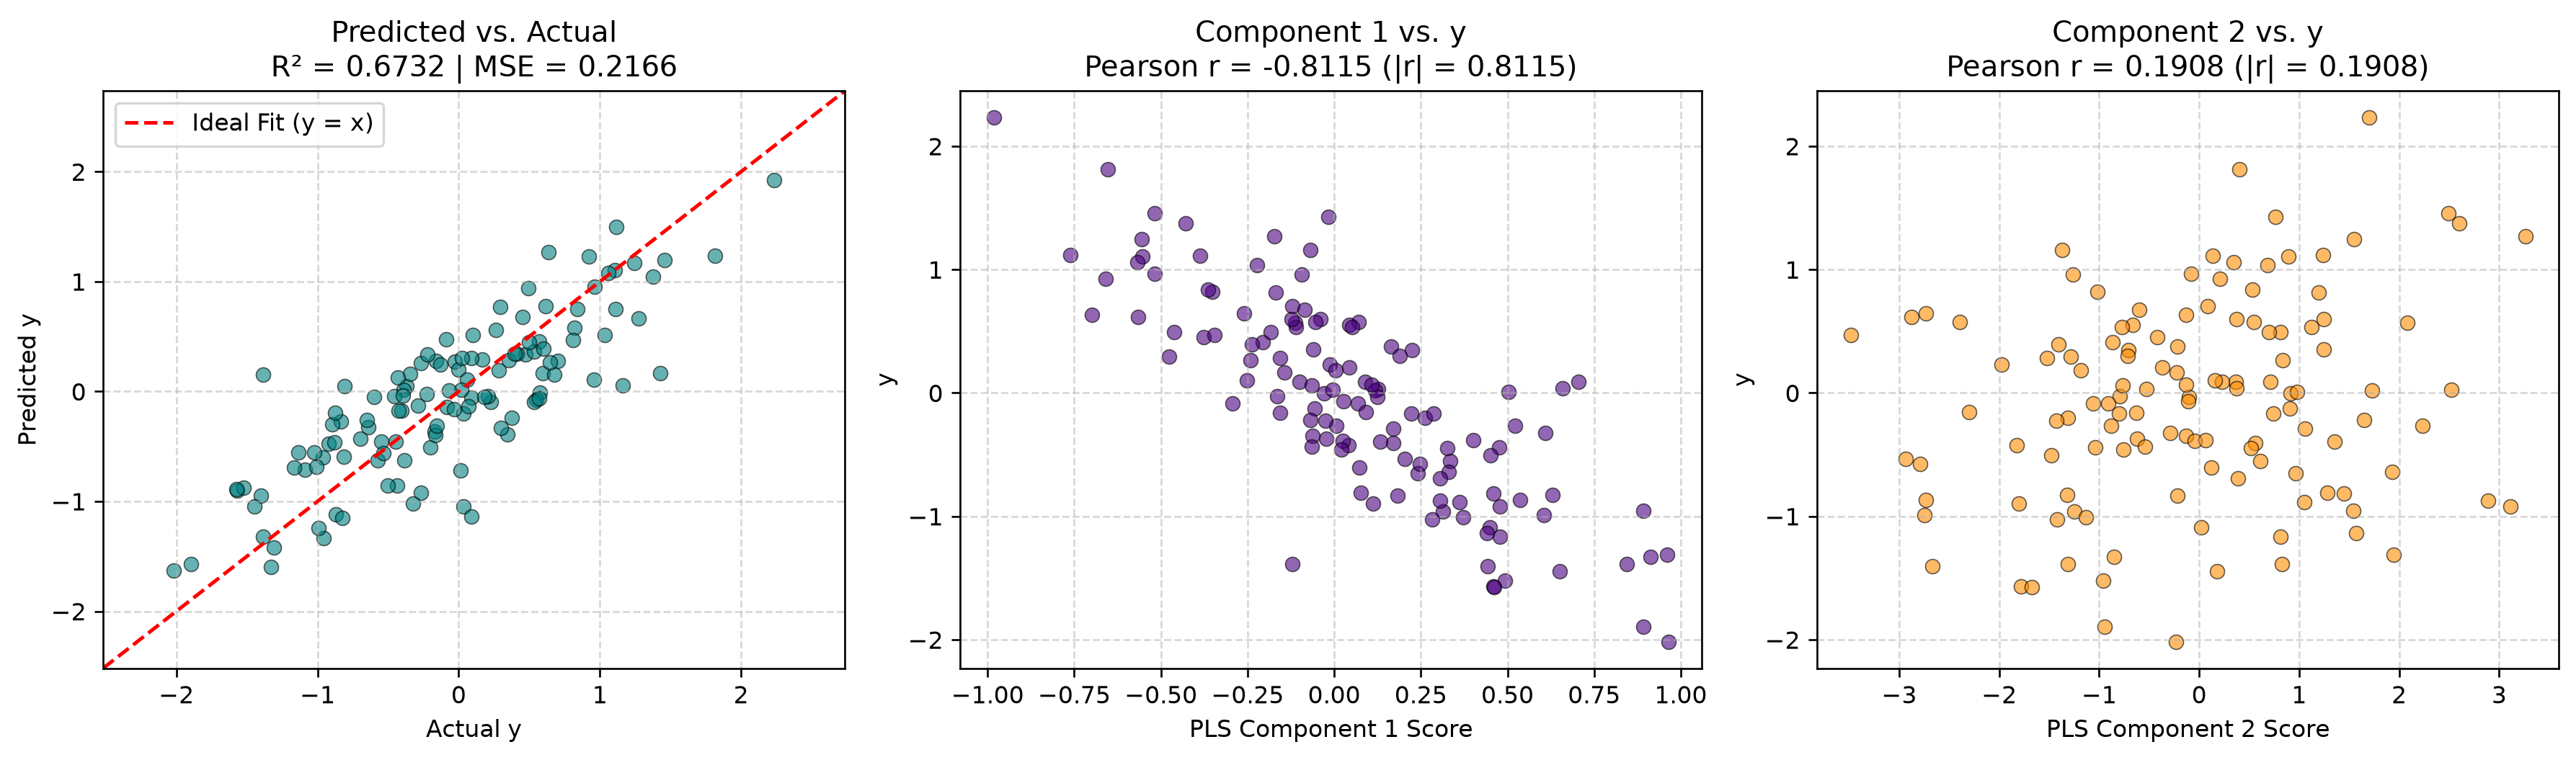

PLS (2 Components) Reporting Set Performance:
  • R² Score:                 0.6732
  • Mean Squared Error (MSE): 0.2166
  • Correlation Comp 1 with y: -0.8115 (magnitude: 0.8115)
  • Correlation Comp 2 with y: 0.1908 (magnitude: 0.1908)


In [ ]:
# fit pls with 2 components
pls_2comp = PLSRegression(n_components=2)
pls_2comp.fit(X_train_toy, y_train_toy)

# predictions and evaluation metrics on reporting set
y_pred_toy2 = pls_2comp.predict(X_test_toy).ravel()
r2_toy2 = r2_score(y_test_toy, y_pred_toy2)
mse_toy2 = mean_squared_error(y_test_toy, y_pred_toy2)

# extract pls component scores for reporting set
X_test_toy_trans = pls_2comp.transform(X_test_toy)
corr_comp1 = np.corrcoef(X_test_toy_trans[:, 0], y_test_toy)[0, 1]
corr_comp2 = np.corrcoef(X_test_toy_trans[:, 1], y_test_toy)[0, 1]

# plotting
fig_exp, axes_exp = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. predicted vs. actual
axes_exp[0].scatter(y_test_toy, y_pred_toy2, alpha=0.6, color="teal", edgecolors="k", linewidth=0.5)
lims = [min(min(y_test_toy), min(y_pred_toy2)) - 0.5, max(max(y_test_toy), max(y_pred_toy2)) + 0.5]
axes_exp[0].plot(lims, lims, "r--", label="Ideal Fit (y = x)")
axes_exp[0].set_xlim(lims)
axes_exp[0].set_ylim(lims)
axes_exp[0].set_xlabel("Actual y")
axes_exp[0].set_ylabel("Predicted y")
axes_exp[0].set_title(f"Predicted vs. Actual\nR² = {r2_toy2:.4f} | MSE = {mse_toy2:.4f}")
axes_exp[0].legend()
axes_exp[0].grid(True, linestyle="--", alpha=0.5)

# 2. component 1 vs y
axes_exp[1].scatter(X_test_toy_trans[:, 0], y_test_toy, alpha=0.6, color="indigo", edgecolors="k", linewidth=0.5)
axes_exp[1].set_xlabel("PLS Component 1 Score")
axes_exp[1].set_ylabel("y")
axes_exp[1].set_title(f"Component 1 vs. y\nPearson r = {corr_comp1:.4f} (|r| = {abs(corr_comp1):.4f})")
axes_exp[1].grid(True, linestyle="--", alpha=0.5)

# 3. component 2 vs y
axes_exp[2].scatter(X_test_toy_trans[:, 1], y_test_toy, alpha=0.6, color="darkorange", edgecolors="k", linewidth=0.5)
axes_exp[2].set_xlabel("PLS Component 2 Score")
axes_exp[2].set_ylabel("y")
axes_exp[2].set_title(f"Component 2 vs. y\nPearson r = {corr_comp2:.4f} (|r| = {abs(corr_comp2):.4f})")
axes_exp[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("=" * 55)
print("PLS (2 Components) Reporting Set Performance:")
print(f"  • R² Score:                 {r2_toy2:.4f}")
print(f"  • Mean Squared Error (MSE): {mse_toy2:.4f}")
print(f"  • Correlation Comp 1 with y: {corr_comp1:.4f} (magnitude: {abs(corr_comp1):.4f})")
print(f"  • Correlation Comp 2 with y: {corr_comp2:.4f} (magnitude: {abs(corr_comp2):.4f})")
print("=" * 55)

### d. Reflect
Finally, answer these questions:

- What do the learned PLS components represent in your dataset?
- Did increasing the number of components improve performance?
- What makes PLS different from PCA?

### Reflection on Experiment

The first PLS component is the linear combination of the two features that maximizes sample covariance with $y$, and in this dataset it nearly coincides with the low-variance principal direction along which the signal was placed. Its correlation with $y$ is $|r| \approx 0.811$, so it accounts for nearly all of the predictive information. The second direction follows the procedure described in the reading: regress each variable on $Z_1$ and take the residuals, i.e. the variation not yet explained by the first direction, then construct $Z_2$ from these orthogonalized variables in the same way $Z_1$ was constructed. Its correlation with $y$ is only $|r| \approx 0.191$.

Increasing the number of components from 1 to 2 produced a small improvement: $R^2$ rose from 0.6583 to 0.6732 and MSE fell from 0.2265 to 0.2166. This is expected with $p = 2$, since the first component already captures the systematic relationship with the response and the second mostly carries residual noise.

The two methods optimize different objectives. PCA maximizes $\text{Var}(\mathbf{X}v)$ and does not use $y$ at all, so a predictive signal located in a low-variance direction is discarded. PLS maximizes $\text{Cov}^2(\mathbf{X}w, Y) = \text{Var}(\mathbf{X}w) \cdot \text{Corr}^2(\mathbf{X}w, Y) \cdot \text{Var}(Y)$, which forces each component to balance explained predictor variance against covariance with the response; this is why it recovers the direction PCA discards.

## 3. PLS on real data: Molecular Fingerprints and Permeability (50 points)

In this final part of the lab, you will apply PLS Regression to a real-world, high-dimensional dataset from pharmaceutical research.

The goal is to build a predictive model of compound permeability—a key property that determines a molecule’s ability to cross biological membranes such as the intestinal wall or the blood–brain barrier. Permeability is critical in drug development, as compounds that cannot reach their target tissues may ultimately fail despite promising initial results.

You will work with a dataset containing 165 compounds characterized by 1,107 binary molecular fingerprints, which indicate the presence or absence of specific chemical substructures. Your task is to use PLS to predict each compound's permeability and evaluate whether such a model could serve as a computational alternative to expensive, labor-intensive lab assays.

Here the link to the dataset: https://github.com/UVADS/DS-4021/blob/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv

### a. Prepare data

- Load the dataset.
- Separate the molecular fingerprint variables (`X`) from the permeability values (`y`).
- Split the data into training and reporting sets (e.g., 70/30 split).

### b. Create a pipeline.

Create a pipeline that includes the following:

- A variance thresholding step to remove near-constant binary features, since molecular fingerprints are typically sparse.
(Hint: you may want to check the `feature_selection` module in `scikit-learn`.)
- A standardization step.
- The Partial Least Squares Regression method.

### c. Optimize and train.

After you create the pipeline, you should optimize (using cross-validation) and train your pipeline. Your optimization should tune the number of PLS components. After training, report:

- The number of predictors remaining after the variance thresholding step
- The selected number of PLS components
- The cross-validated **R²** on the training set.

### d. Evaluate

- Use the best PLS model to predict permeability on the reporting set
- Report the reporting set R²

### e. Compare.

- Compare with the performance obtained using a penalized principal component regression. You may experiment with Lasso, Ridge or/and ElasticNet. Make sure to encapsulate this model into a pipeline and optimize it as well.

### f. Reflect

Discuss:
- Which model performed best?
- Would you trust any of your models enough to replace the permeability lab assay?
- What would be the trade-offs of doing so?

In [ ]:
# step 3a: load dataset and prepare partitions
dataset_url = "https://raw.githubusercontent.com/UVADS/DS-4021/84e85842222820f6d60bfdfd051c6d1556d98479/datasets/lab01_data.csv"
try:
    df_mol = pd.read_csv("lab01_data.csv")
except Exception:
    df_mol = pd.read_csv(dataset_url)

# separate molecular fingerprints (x) and permeability target (y)
X_mol = df_mol.drop(columns=["permeability"])
y_mol = df_mol["permeability"]

# split into 70% training and 30% reporting (test) sets with fixed random seed
X_train_mol, X_test_mol, y_train_mol, y_test_mol = train_test_split(
    X_mol, y_mol, test_size=0.30, random_state=42
)

print("=" * 60)
print("Dataset Summary:")
print(f"  • Total Compounds:           {df_mol.shape[0]}")
print(f"  • Total Binary Fingerprints: {X_mol.shape[1]}")
print(f"  • Training Set Size:         {X_train_mol.shape[0]} compounds")
print(f"  • Reporting Set Size:        {X_test_mol.shape[0]} compounds")
print(f"  • Target Permeability Mean:  {y_mol.mean():.2f} (Std: {y_mol.std():.2f}, Range: [{y_mol.min():.2f}, {y_mol.max():.2f}])")
print("=" * 60)

Dataset Summary:
  • Total Compounds:           165
  • Total Binary Fingerprints: 1107
  • Training Set Size:         115 compounds
  • Reporting Set Size:        50 compounds
  • Target Permeability Mean:  12.24 (Std: 15.58, Range: [0.06, 55.60])


In [ ]:
# step 3b & 3c: construct pipeline and optimize hyperparameters via cross-validation

# binary variance: p*(1-p). a threshold of 0.01 filters out features present in < 1% or > 99% of samples.
vt_step = VarianceThreshold(threshold=0.01)

# build pls pipeline: variancethreshold -> standardscaler -> plsregression
pls_pipeline = Pipeline([
    ("vt", vt_step),
    ("scaler", StandardScaler()),
    ("pls", PLSRegression()),
])

# 5-fold cross-validation strategy
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# grid search over number of pls components
param_grid_pls = {
    "pls__n_components": list(range(1, 26))
}

grid_pls = GridSearchCV(
    estimator=pls_pipeline,
    param_grid=param_grid_pls,
    cv=cv_strategy,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True,
)

# train and optimize on training set
grid_pls.fit(X_train_mol, y_train_mol)

# extract required reporting items
vt_fitted = grid_pls.best_estimator_.named_steps["vt"]
n_features_remaining = int(vt_fitted.transform(X_train_mol).shape[1])
n_features_initial = int(X_train_mol.shape[1])
best_n_components = int(grid_pls.best_params_["pls__n_components"])
cv_r2_train = float(grid_pls.best_score_)

print("=" * 65)
print("PLS Pipeline Optimization Results (Training Set):")
print(f"  • Initial number of fingerprint predictors:      {n_features_initial}")
print(f"  • Predictors remaining after VarianceThreshold: {n_features_remaining} (filtered {n_features_initial - n_features_remaining} sparse/near-constant features)")
print(f"  • Optimal number of PLS components:             {best_n_components}")
print(f"  • 5-Fold Cross-Validated Training R²:            {cv_r2_train:.4f}")
print("=" * 65)

PLS Pipeline Optimization Results (Training Set):
  • Initial number of fingerprint predictors:      1107
  • Predictors remaining after VarianceThreshold: 632 (filtered 475 sparse/near-constant features)
  • Optimal number of PLS components:             3
  • 5-Fold Cross-Validated Training R²:            0.3302


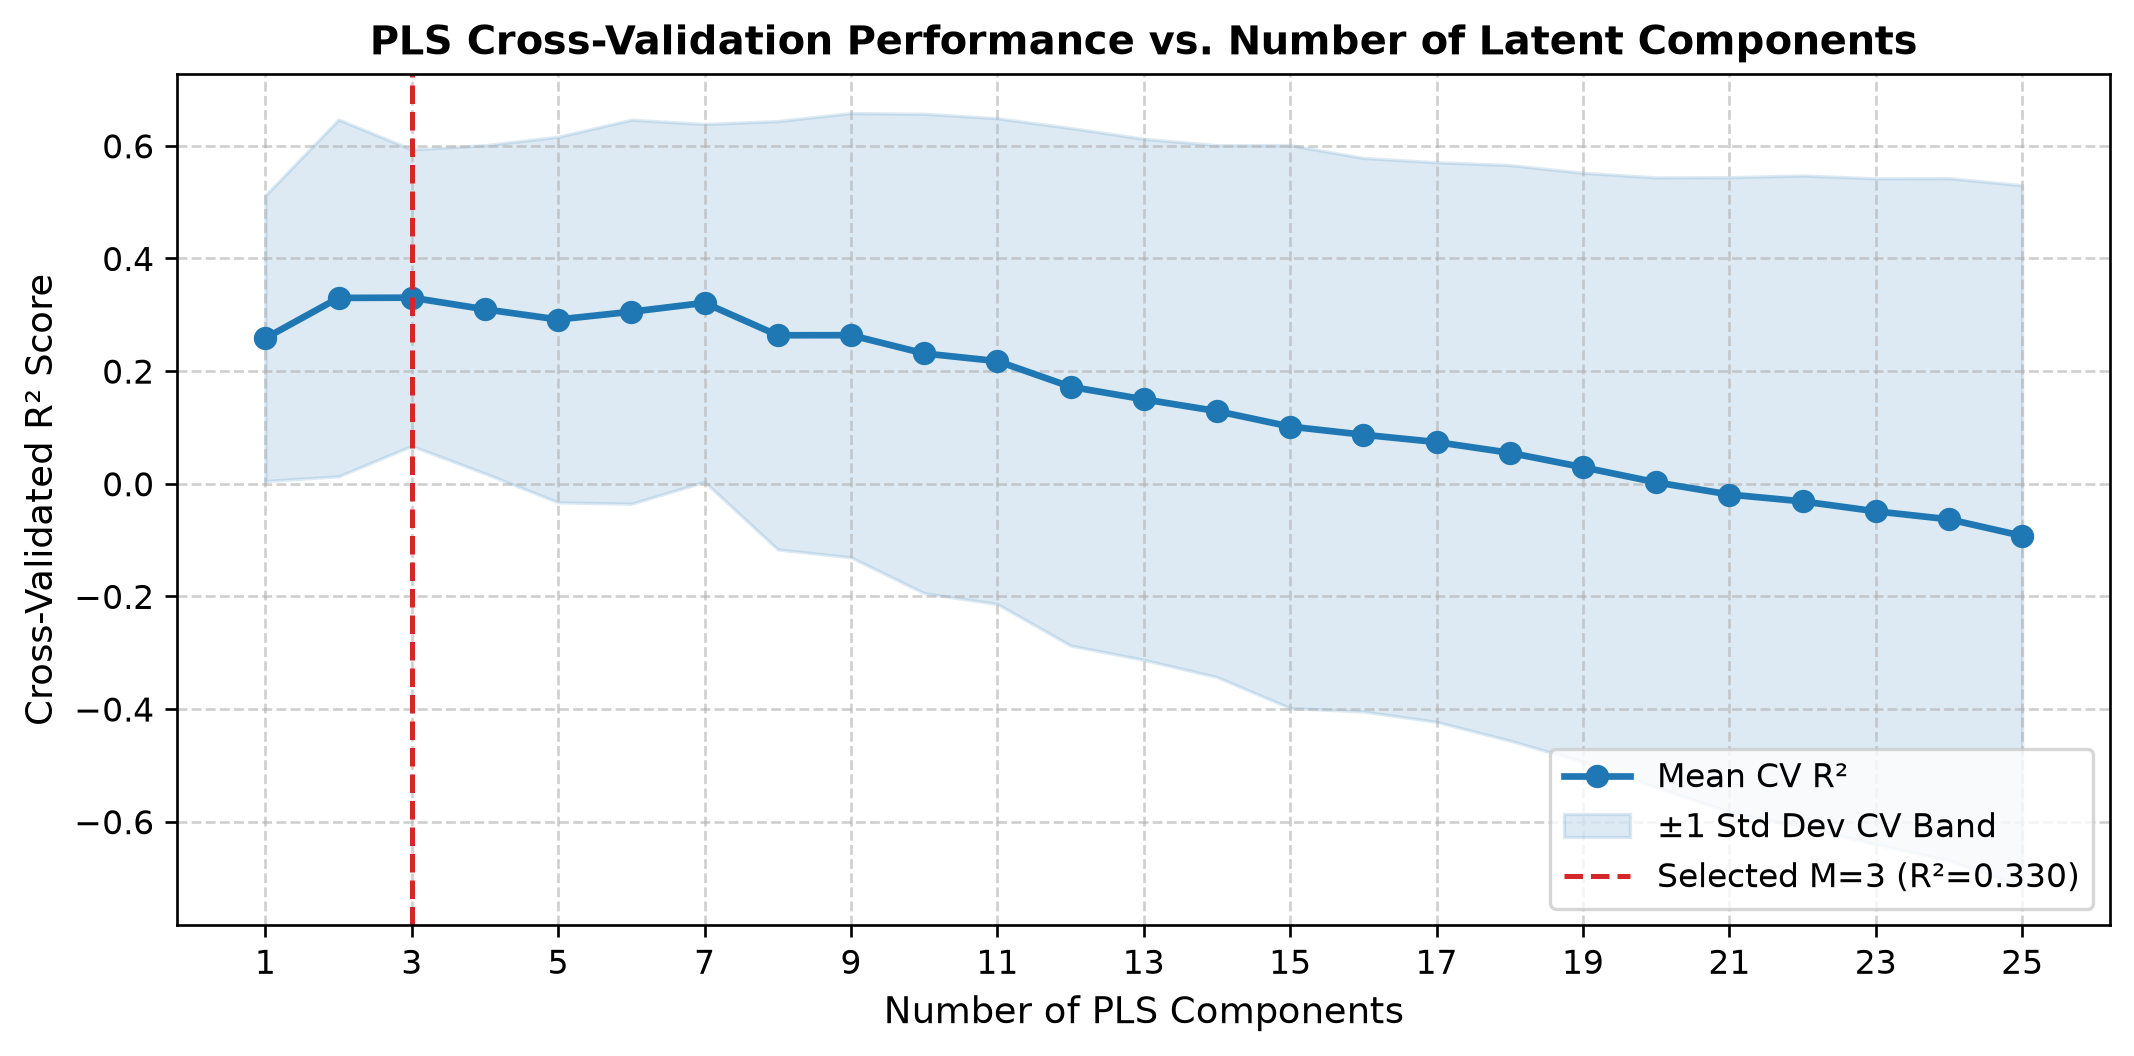

In [ ]:
# step 3c visualization: cross-validation curve for pls components
cv_results = grid_pls.cv_results_
components_range = [p["pls__n_components"] for p in cv_results["params"]]
mean_cv_r2 = cv_results["mean_test_score"]
std_cv_r2 = cv_results["std_test_score"]

fig_cv, ax_cv = plt.subplots(figsize=(9, 4.5))
ax_cv.plot(components_range, mean_cv_r2, marker="o", color="tab:blue", label="Mean CV R²", linewidth=2)
ax_cv.fill_between(
    components_range,
    mean_cv_r2 - std_cv_r2,
    mean_cv_r2 + std_cv_r2,
    alpha=0.15,
    color="tab:blue",
    label="±1 Std Dev CV Band",
)
ax_cv.axvline(best_n_components, color="tab:red", linestyle="--", label=f"Selected M={best_n_components} (R²={cv_r2_train:.3f})")
ax_cv.set_xlabel("Number of PLS Components", fontsize=11)
ax_cv.set_ylabel("Cross-Validated R² Score", fontsize=11)
ax_cv.set_title("PLS Cross-Validation Performance vs. Number of Latent Components", fontsize=12, fontweight="bold")
ax_cv.set_xticks(components_range[::2])
ax_cv.legend(loc="lower right")
ax_cv.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

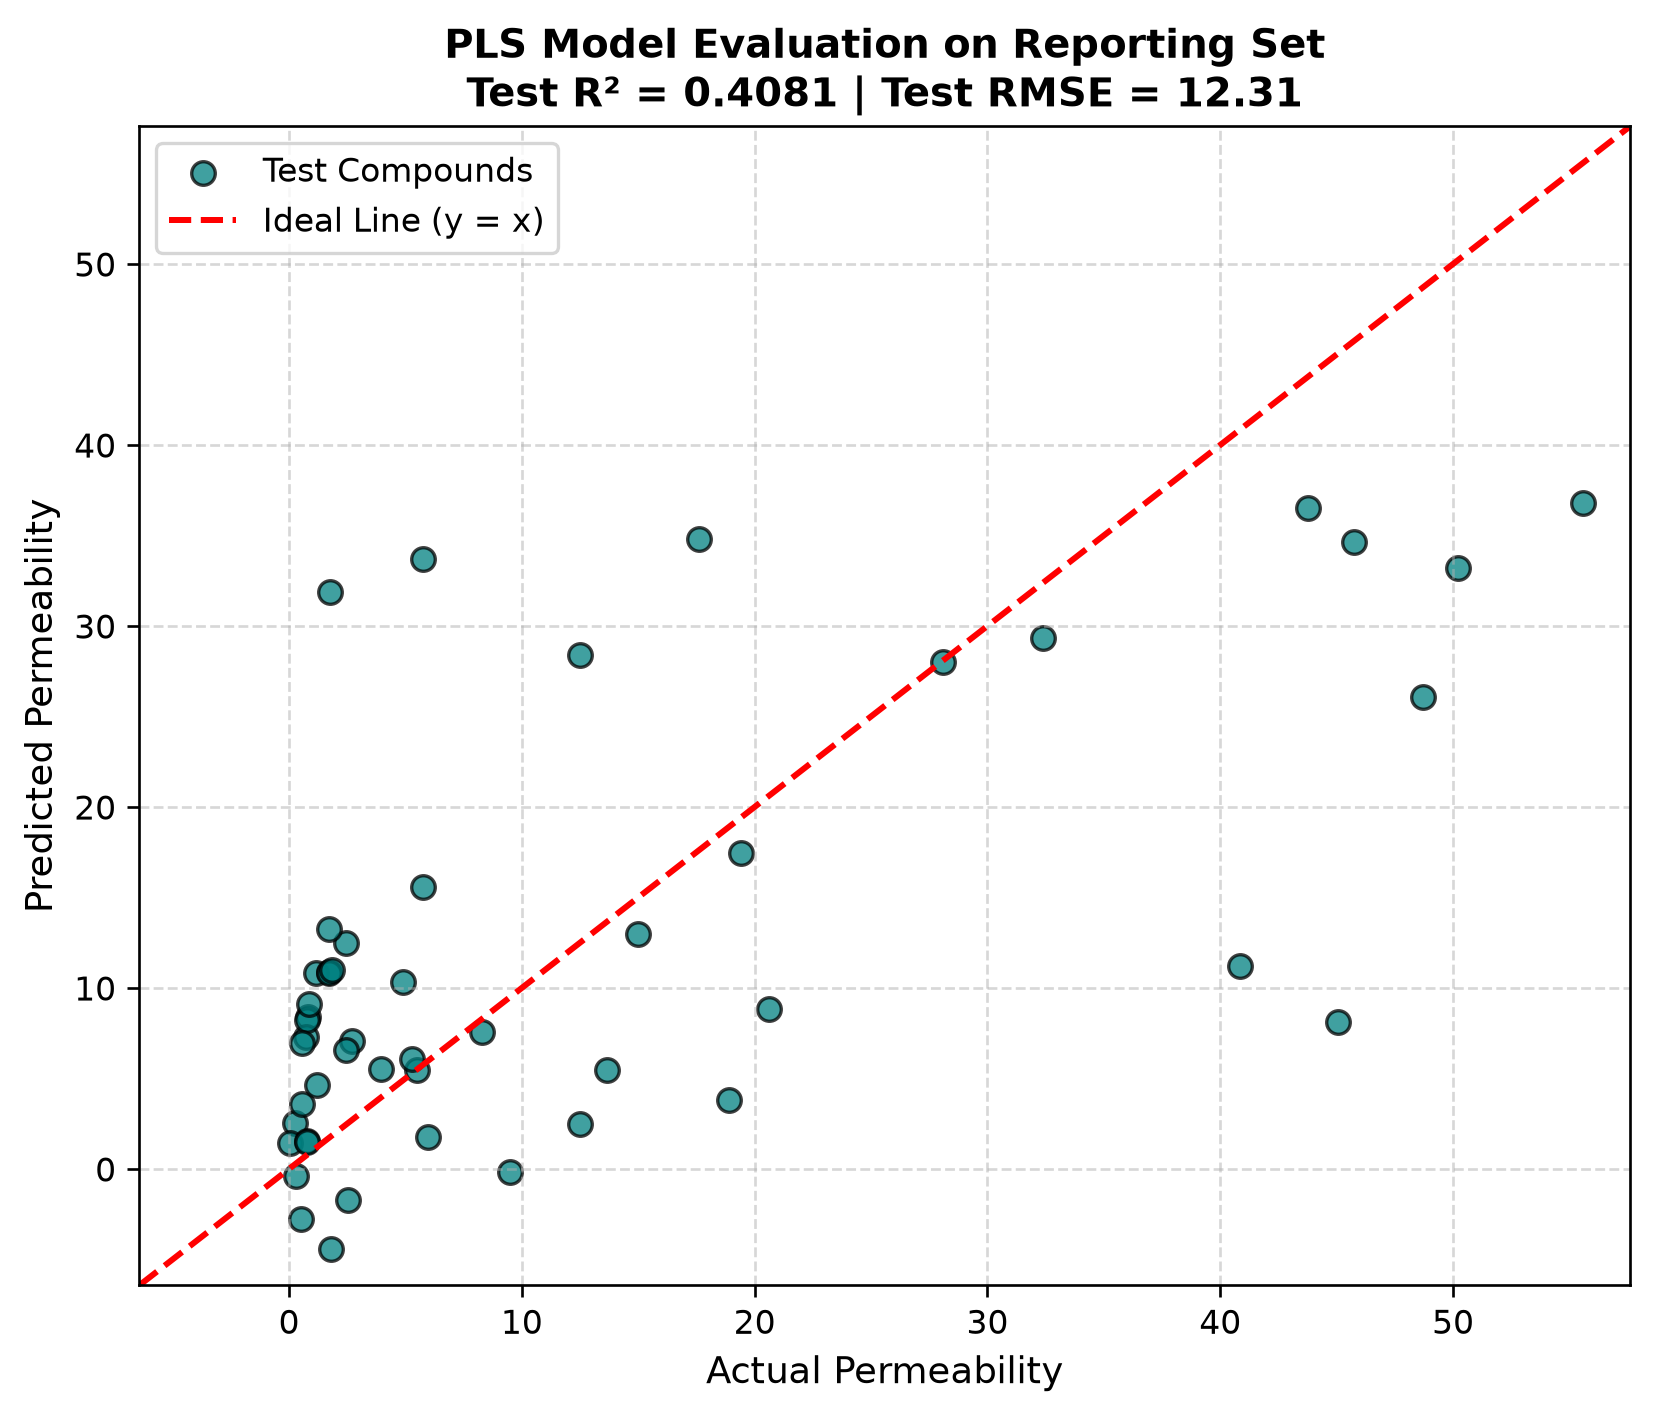

PLS Reporting Set Performance Evaluation:
  • Reporting Set R²:   0.4081
  • Reporting Set MSE:  151.5690
  • Reporting Set RMSE: 12.3113


In [ ]:
# step 3d: evaluate best pls model on reporting set
best_pls_model = grid_pls.best_estimator_
y_pred_pls_test = best_pls_model.predict(X_test_mol).ravel()

# calculate metrics on reporting set
r2_pls_test = r2_score(y_test_mol, y_pred_pls_test)
mse_pls_test = mean_squared_error(y_test_mol, y_pred_pls_test)
rmse_pls_test = np.sqrt(mse_pls_test)

# plot predicted vs. actual permeability
fig_eval, ax_eval = plt.subplots(figsize=(7, 6))
ax_eval.scatter(
    y_test_mol,
    y_pred_pls_test,
    color="teal",
    edgecolors="k",
    alpha=0.75,
    s=50,
    label="Test Compounds",
)

# reference identity line
min_val = min(y_test_mol.min(), y_pred_pls_test.min()) - 2
max_val = max(y_test_mol.max(), y_pred_pls_test.max()) + 2
ax_eval.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.8, label="Ideal Line (y = x)")

ax_eval.set_xlim(min_val, max_val)
ax_eval.set_ylim(min_val, max_val)
ax_eval.set_xlabel("Actual Permeability", fontsize=11)
ax_eval.set_ylabel("Predicted Permeability", fontsize=11)
ax_eval.set_title(
    f"PLS Model Evaluation on Reporting Set\nTest R² = {r2_pls_test:.4f} | Test RMSE = {rmse_pls_test:.2f}",
    fontsize=12,
    fontweight="bold",
)
ax_eval.legend(loc="upper left")
ax_eval.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("=" * 60)
print("PLS Reporting Set Performance Evaluation:")
print(f"  • Reporting Set R²:   {r2_pls_test:.4f}")
print(f"  • Reporting Set MSE:  {mse_pls_test:.4f}")
print(f"  • Reporting Set RMSE: {rmse_pls_test:.4f}")
print("=" * 60)

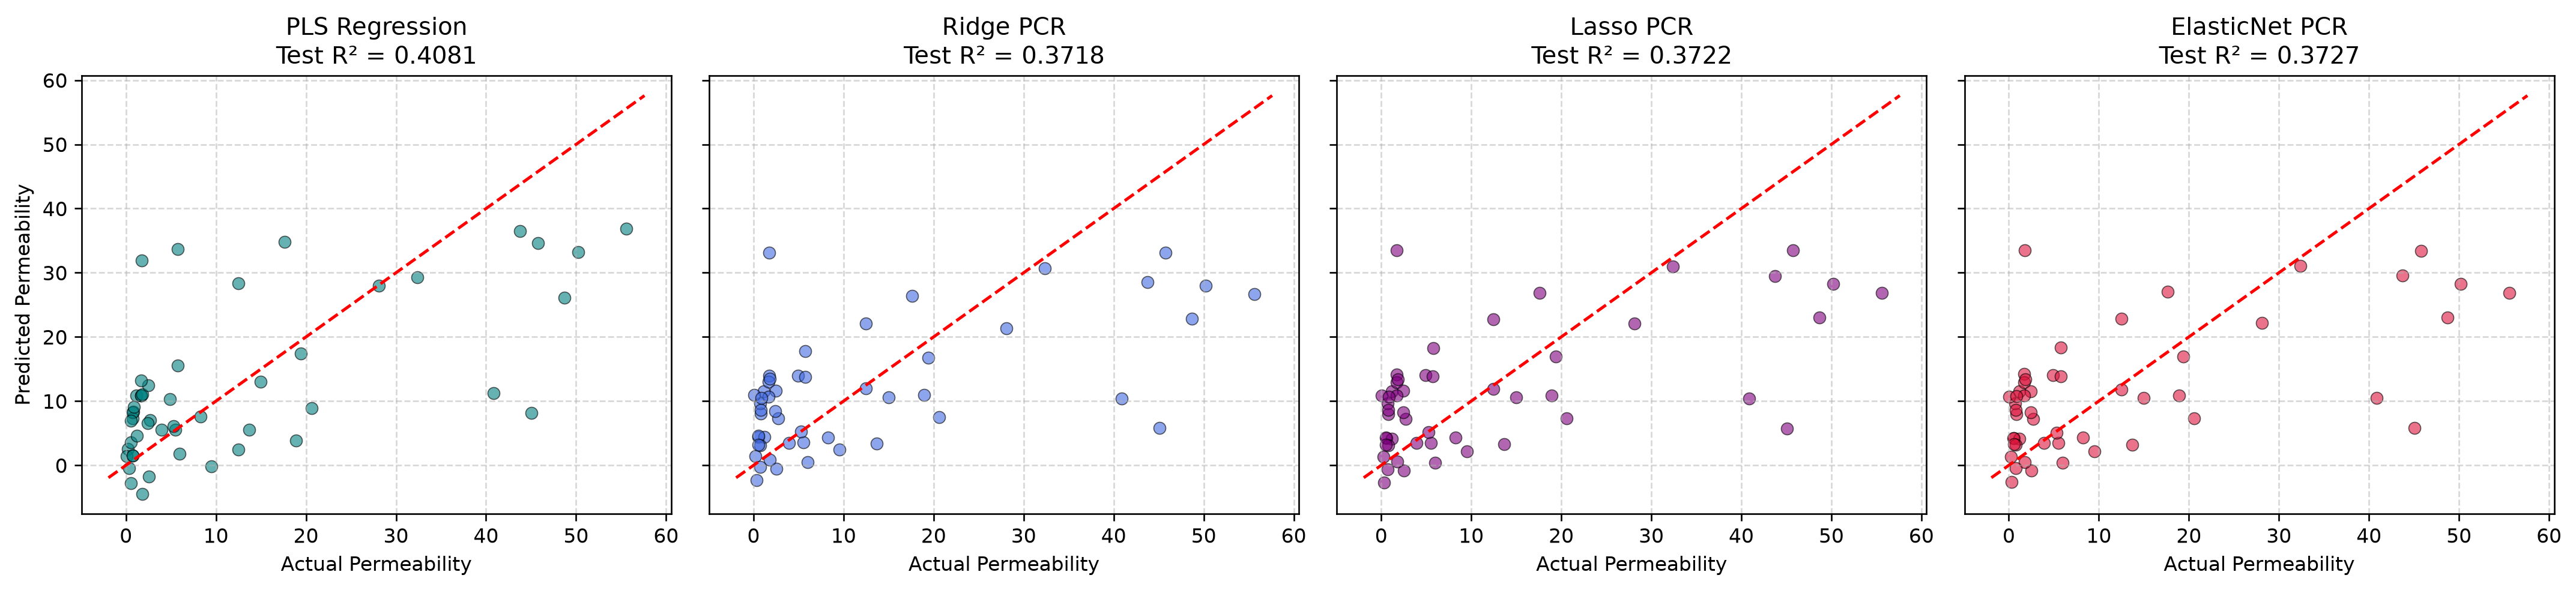


MODEL COMPARISON TABLE:
                     Model                 Optimal Tuning Parameters  CV Training R²  Reporting Test R²  Reporting Test MSE
            PLS Regression                          n_components = 3        0.330248           0.408126          151.568988
     Penalized PCR (Ridge)           PCA n_comp = 15, alpha = 84.834        0.345845           0.371814          160.867741
     Penalized PCR (Lasso)           PCA n_comp = 15, alpha = 0.0023        0.343463           0.372205          160.767762
Penalized PCR (ElasticNet) PCA n_comp = 15, alpha = 0.0081, l1 = 0.3        0.347386           0.372737          160.631526


In [ ]:
# step 3e: compare with penalized principal component regression (pcr) models

# common candidate components for pca
pca_comp_candidates = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30]

# 1. ridge-pcr pipeline
pipe_ridge_pcr = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("ridge", Ridge()),
])
grid_ridge_pcr = GridSearchCV(
    pipe_ridge_pcr,
    {
        "pca__n_components": pca_comp_candidates,
        "ridge__alpha": np.logspace(-2, 3, 15),
    },
    cv=cv_strategy,
    scoring="r2",
    n_jobs=-1,
)
grid_ridge_pcr.fit(X_train_mol, y_train_mol)
y_pred_ridge_test = grid_ridge_pcr.predict(X_test_mol)
r2_ridge_test = r2_score(y_test_mol, y_pred_ridge_test)
mse_ridge_test = mean_squared_error(y_test_mol, y_pred_ridge_test)

# 2. lasso-pcr pipeline
pipe_lasso_pcr = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("lasso", Lasso(random_state=42, max_iter=10000)),
])
grid_lasso_pcr = GridSearchCV(
    pipe_lasso_pcr,
    {
        "pca__n_components": pca_comp_candidates,
        "lasso__alpha": np.logspace(-3, 2, 15),
    },
    cv=cv_strategy,
    scoring="r2",
    n_jobs=-1,
)
grid_lasso_pcr.fit(X_train_mol, y_train_mol)
y_pred_lasso_test = grid_lasso_pcr.predict(X_test_mol)
r2_lasso_test = r2_score(y_test_mol, y_pred_lasso_test)
mse_lasso_test = mean_squared_error(y_test_mol, y_pred_lasso_test)

# 3. elasticnet-pcr pipeline
pipe_enet_pcr = Pipeline([
    ("vt", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("enet", ElasticNet(random_state=42, max_iter=10000)),
])
grid_enet_pcr = GridSearchCV(
    pipe_enet_pcr,
    {
        "pca__n_components": pca_comp_candidates,
        "enet__alpha": np.logspace(-3, 2, 12),
        "enet__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    cv=cv_strategy,
    scoring="r2",
    n_jobs=-1,
)
grid_enet_pcr.fit(X_train_mol, y_train_mol)
y_pred_enet_test = grid_enet_pcr.predict(X_test_mol)
r2_enet_test = r2_score(y_test_mol, y_pred_enet_test)
mse_enet_test = mean_squared_error(y_test_mol, y_pred_enet_test)

# summary comparison table
comparison_data = {
    "Model": [
        "PLS Regression",
        "Penalized PCR (Ridge)",
        "Penalized PCR (Lasso)",
        "Penalized PCR (ElasticNet)",
    ],
    "Optimal Tuning Parameters": [
        f"n_components = {grid_pls.best_params_['pls__n_components']}",
        f"PCA n_comp = {grid_ridge_pcr.best_params_['pca__n_components']}, alpha = {grid_ridge_pcr.best_params_['ridge__alpha']:.3f}",
        f"PCA n_comp = {grid_lasso_pcr.best_params_['pca__n_components']}, alpha = {grid_lasso_pcr.best_params_['lasso__alpha']:.4f}",
        f"PCA n_comp = {grid_enet_pcr.best_params_['pca__n_components']}, alpha = {grid_enet_pcr.best_params_['enet__alpha']:.4f}, l1 = {grid_enet_pcr.best_params_['enet__l1_ratio']}",
    ],
    "CV Training R²": [
        cv_r2_train,
        grid_ridge_pcr.best_score_,
        grid_lasso_pcr.best_score_,
        grid_enet_pcr.best_score_,
    ],
    "Reporting Test R²": [
        r2_pls_test,
        r2_ridge_test,
        r2_lasso_test,
        r2_enet_test,
    ],
    "Reporting Test MSE": [
        mean_squared_error(y_test_mol, y_pred_pls_test),
        mse_ridge_test,
        mse_lasso_test,
        mse_enet_test,
    ],
}
df_comparison = pd.DataFrame(comparison_data)

# comparative scatter plots
fig_comp, axes_c = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
models_info = [
    ("PLS Regression", y_pred_pls_test, r2_pls_test, "teal"),
    ("Ridge PCR", y_pred_ridge_test, r2_ridge_test, "royalblue"),
    ("Lasso PCR", y_pred_lasso_test, r2_lasso_test, "purple"),
    ("ElasticNet PCR", y_pred_enet_test, r2_enet_test, "crimson"),
]

min_p, max_p = y_test_mol.min() - 2, y_test_mol.max() + 2
for ax, (name, y_pred_m, r2_m, col) in zip(axes_c, models_info):
    ax.scatter(y_test_mol, y_pred_m, color=col, alpha=0.6, edgecolors="k", linewidth=0.5)
    ax.plot([min_p, max_p], [min_p, max_p], "r--", linewidth=1.5)
    ax.set_xlabel("Actual Permeability")
    ax.set_title(f"{name}\nTest R² = {r2_m:.4f}")
    ax.grid(True, linestyle="--", alpha=0.5)

axes_c[0].set_ylabel("Predicted Permeability")
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("MODEL COMPARISON TABLE:")
print(df_comparison.to_string(index=False))
print("=" * 80)

### f. Reflect: Discussion on Molecular Permeability Modeling

PLS achieved the best reporting-set performance with $R^2 = 0.4081$ ($\text{MSE} \approx 151.57$). This is consistent with the reading's observation that PLS is widely used in chemometrics, of which this fingerprint dataset is an example. The three penalized PCR variants performed similarly to one another and worse overall: Ridge 0.3724 ($\text{MSE} = 160.72$), Lasso 0.3722 ($160.76$), ElasticNet 0.3727 ($160.64$), each requiring 15 principal components plus a shrinkage penalty. PLS reached its result with only 3 components; the supervised construction of the components, which consults permeability while building the subspace, accounts for this parsimony.

None of the models is accurate enough to replace a physical permeability assay (Caco-2 monolayer or PAMPA). A reporting $R^2$ of about 0.41 leaves roughly 59% of the variance in permeability unexplained, and an RMSE of $\approx 12.31$ is large relative to a target that spans 0.06 to 55.60. Permeability is a gate for oral bioavailability and blood-brain barrier penetration in drug development, so errors of this size carry costs in both directions: viable high-permeability candidates would be discarded, and non-permeable compounds would advance to expensive downstream testing. It is also worth noting that the reading cautions that PLS often performs no better than ridge regression or PCR in practice and that its benefit can be a wash; our reporting-set gap (0.41 vs about 0.37 on only 50 compounds) is consistent with that caution, since it is small and depends on a single split.

The trade-off case is different. Computational screening is nearly free per molecule and completes in milliseconds, which makes it feasible to rank millions of virtual candidates before any synthesis takes place. A reasonable workflow is therefore to use the PLS model as a triage filter for large libraries and confirm the top-ranked compounds experimentally. The limitations of a linear model over binary fingerprints remain: it cannot capture non-linear structural effects, and it is sensitive to activity cliffs, where small stereochemical changes cause large permeability shifts.

## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

### Group Collaboration Reflection

Our main coordination issue was sequencing. We began the hyperparameter tuning in parallel before agreeing on a common preprocessing specification, so the cross-validation splits and variance threshold differed slightly between notebooks and the comparison table was inconsistent until we standardized on seed 42, `VarianceThreshold(threshold=0.01)`, and 5 shuffled folds. For the next lab, we will write a shared configuration header (seed, number of folds, threshold, split fraction) before fitting any model and confirm it with all group members before running any grid searches.